# PIECEWISE PREDICTIONS

This notebook explores the effect of oscillating species on the accuracy of a linear approximation. The conclusion is that the effect is minimal.

In [1]:
import matplotlib.pyplot as plt  # type: ignore
import numpy as np  # type: ignore
import os
import pandas as pd  # type: ignore
from src.timecourse_iterator import TimecourseIterator # type: ignore
from typing import Optional, cast, List, Union

import src.constants as cn
from src.score import Score
from src.system_discovery import SystemDiscovery  # type: ignore
from src.piecewise_system_discovery import PiecewiseSystemDiscovery
from src.model import Model
from src.timecourse import Timecourse
from src.system_discovery_changepoint_detector import SystemDiscoveryChangepointDetector

# Initializations

In [2]:
# Non-oscillating species timecourses
path = os.path.join(cn.DATA_DIR, f"find_oscillating_models.csv")
NONOSCILLATION_DF = pd.read_csv(path)
NONOSCILLATION_DF = NONOSCILLATION_DF [NONOSCILLATION_DF[cn.COL_FREQUENCIES] == "[]"]
NONOSCILLATION_DF = NONOSCILLATION_DF [NONOSCILLATION_DF[cn.COL_SPECIES_NAME] != cn.COL_AGGREGATION_TYPE_MODEL]
NONOSCILLATION_DF["key"] = [m + "_" + str(s) for m, s in zip(NONOSCILLATION_DF[cn.COL_SYSTEM_ID], NONOSCILLATION_DF[cn.COL_SPECIES_NAME])]
NONOSCILLATION_DF

,system_id,species_name,frequencies,endtime,key
17,BIOMD0000000042,GLC,[],300.0,BIOMD0000000042_GLC
19,BIOMD0000000042,FBP,[],300.0,BIOMD0000000042_FBP
20,BIOMD0000000042,GAP,[],300.0,BIOMD0000000042_GAP
21,BIOMD0000000042,NAD,[],300.0,BIOMD0000000042_NAD
22,BIOMD0000000042,NADH,[],300.0,BIOMD0000000042_NADH
...,...,...,...,...,...
4552,BIOMD0000001059,sursmac,[],7000.0,BIOMD0000001059_sursmac
4553,BIOMD0000001059,smacmit,[],7000.0,BIOMD0000001059_smacmit
4554,BIOMD0000001059,smac,[],7000.0,BIOMD0000001059_smac
4555,BIOMD0000001060,x1,[],40.0,BIOMD0000001060_x1


# Individual models

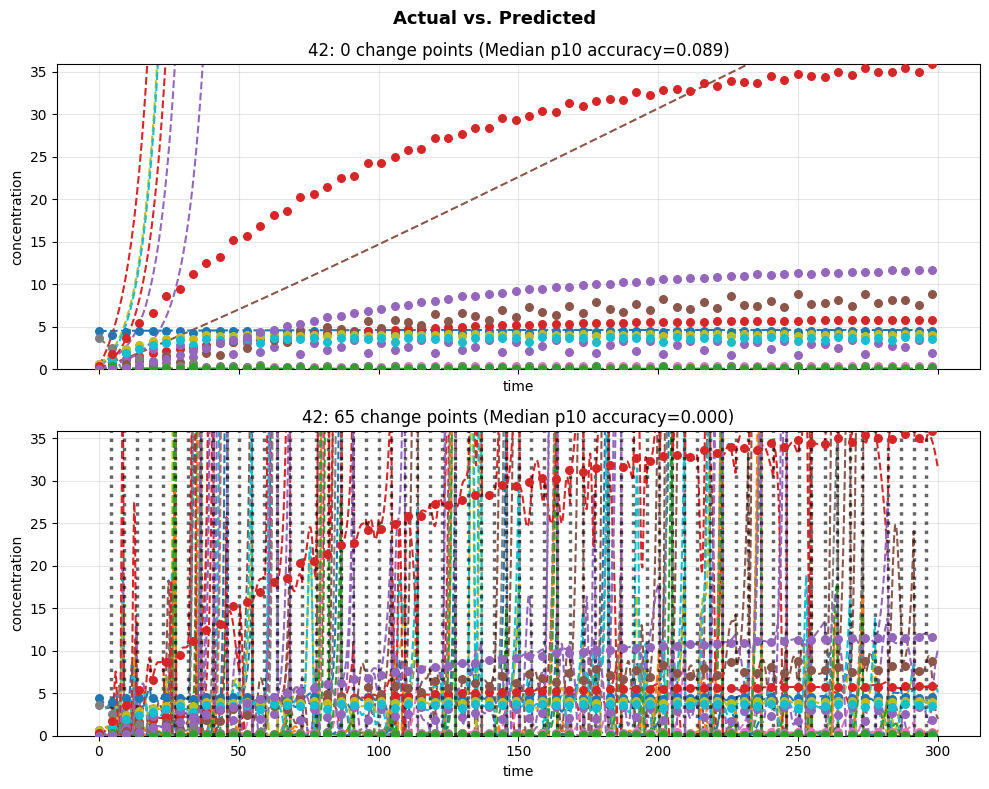

In [34]:
#for model_num in [45, 548, 551, 1045]:
#for model_num in []:
for model_num in [42]:
    model = Model.makeBiomodel(model_num=model_num)
    timecourse = Timecourse(model, num_point =1000)
    df = timecourse.timecourse_df
    specified_changepoints = list(range(10, 980, 30))
    try:
        psd = PiecewiseSystemDiscovery(df, 
                                       #changepoints=specified_changepoints,
                                       max_changepoint=100,
                                       is_changepoint_removal=False,
                                        max_fractional_reduction=0.01, model_name=str(model_num))
        psd.fit()
        result = psd.plotPiecewise(legend=False, num_true_point=60)
    except Exception as e:
        print(f"Could not process {model_num}: {e}")

# Distribution of Number Species Across models

In [9]:
num_species_dct = {}
for item in TimecourseIterator():
    num_species_dct.update({item.model_name: len(item.timecourse.timecourse_df.columns)})
len(num_species_dct)

430

In [10]:
[m for m, s in num_species_dct.items() if s > 100]

['BIOMD0000000474', 'BIOMD0000000667']

In [11]:
num_species_dct.values()

dict_values([6, 8, 15, 2, 3, 3, 19, 54, 54, 19, 10, 7, 5, 5, 11, 4, 6, 3, 3, 3, 79, 104, 43, 0, 0, 9, 2, 6, 45, 3, 3, 3, 2, 2, 36, 0, 5, 2, 89, 0, 24, 21, 15, 58, 26, 2, 49, 20, 8, 15, 30, 29, 50, 10, 25, 61, 4, 11, 11, 53, 3, 29, 3, 15, 15, 7, 3, 3, 6, 8, 103, 10, 5, 3, 7, 2, 0, 46, 13, 13, 1, 2, 3, 3, 3, 5, 4, 10, 4, 15, 16, 7, 7, 13, 8, 9, 12, 11, 13, 5, 24, 23, 24, 24, 11, 16, 32, 45, 5, 5, 7, 10, 3, 3, 4, 4, 4, 4, 16, 5, 8, 5, 5, 25, 28, 8, 2, 3, 3, 3, 22, 11, 11, 11, 24, 32, 4, 5, 5, 3, 33, 4, 2, 8, 2, 3, 2, 3, 9, 4, 7, 2, 6, 2, 6, 2, 3, 4, 4, 5, 3, 5, 5, 4, 3, 4, 3, 2, 4, 2, 3, 3, 6, 4, 3, 2, 3, 3, 2, 15, 2, 8, 3, 4, 5, 6, 2, 2, 5, 4, 5, 2, 3, 4, 4, 3, 4, 6, 3, 6, 5, 13, 6, 4, 3, 3, 2, 6, 6, 10, 10, 7, 3, 8, 16, 1, 2, 13, 10, 5, 11, 6, 3, 20, 61, 75, 31, 2, 8, 3, 8, 5, 20, 10, 9, 3, 3, 9, 13, 3, 5, 6, 9, 4, 4, 20, 9, 8, 12, 3, 26, 8, 6, 6, 10, 7, 29, 4, 4, 4, 4, 3, 3, 4, 4, 63, 3, 4, 5, 4, 4, 12, 3, 3, 4, 3, 3, 9, 9, 2, 5, 12, 3, 4, 5, 4, 5, 3, 25, 7, 4, 3, 3, 3, 6, 5, 9, 5, 3, 

Text(0.5, 1.0, 'Number Species per Model')

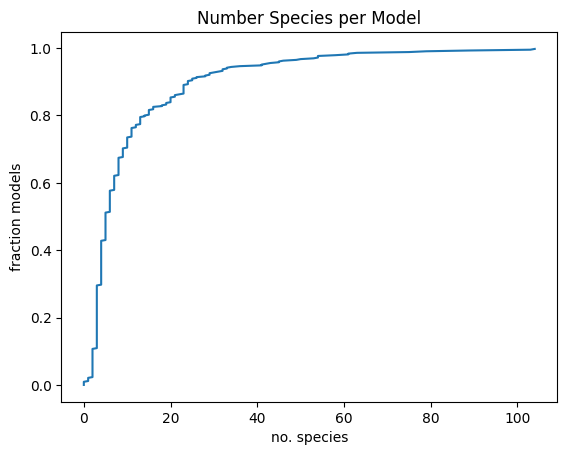

In [12]:
values = np.sort(list(num_species_dct.values()))
yv = np.array(range(len(values)))/len(values)
plt.plot(values, yv)
plt.xlabel("no. species")
plt.ylabel("fraction models")
plt.title("Number Species per Model")

Text(0.5, 1.0, 'CDF of Species by Model Size')

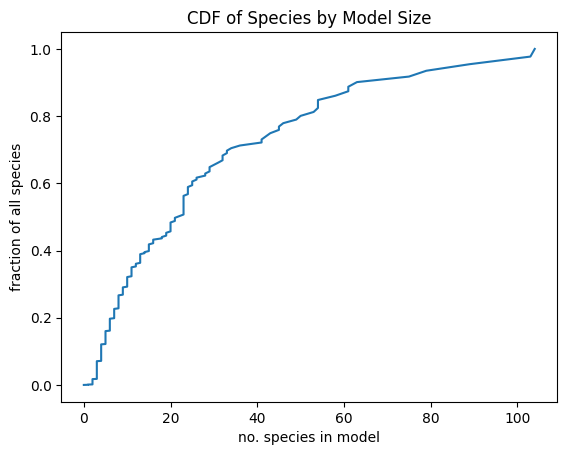

In [13]:
frac_species = np.cumsum(values)/np.sum(values)
_, ax = plt.subplots(1)
ax.plot(values, frac_species)
ax.set_xlabel("no. species in model")
ax.set_ylabel("fraction of all species")
ax.set_title("CDF of Species by Model Size")

# CDFs

## All Models

In [14]:
threshold = 0.001
#path = os.path.join(cn.DATA_DIR, f"piecewise_predictions_{threshold}.csv")
path = os.path.join(cn.DATA_DIR, f"piecewise_predictions.csv")
DF = pd.read_csv(path)
DF

,system_id,aggregation_type,mean,min,max,count,invalid_count,p05,p10,p20,...,p95,p99,a80,a90,a95,max_changepoint,min_segment_length,max_fractional_reduction,coefficient_threshold,num_changepoint
0,BIOMD0000000005,model,0.000000,0.000000,0.000000,6,0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000,0.000,0,50,0.01,0.001,0
1,BIOMD0000000005,C2,0.004453,0.000000,0.857498,999,1,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.002002,0.000,0.000,0,50,0.01,0.001,0
2,BIOMD0000000005,CP,0.006316,0.000000,1.000000,1000,0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.005000,0.004,0.003,0,50,0.01,0.001,0
3,BIOMD0000000005,M,0.000000,0.000000,0.000000,999,1,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000,0.000,0,50,0.01,0.001,0
4,BIOMD0000000005,pM,0.002001,0.000000,1.000000,1000,0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.002000,0.001,0.001,0,50,0.01,0.001,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30549,BIOMD0000001060,x1,0.991918,0.931757,1.000000,1000,0,0.968643,0.971710,0.981305,...,0.999998,1.000000,1.000000,1.000,0.989,19,50,0.01,0.001,4
30550,BIOMD0000001060,x2,0.993014,0.624593,1.000000,1000,0,0.991153,0.991868,0.994175,...,0.999997,1.000000,0.995000,0.980,0.966,19,50,0.01,0.001,4
30551,BIOMD0000001060,model,0.878286,0.816801,0.939771,2,0,0.822949,0.829098,0.841395,...,0.933623,0.938541,1.000000,0.500,0.000,20,50,0.01,0.001,4
30552,BIOMD0000001060,x1,0.979144,0.670801,1.000000,1000,0,0.839101,0.939771,0.995401,...,1.000000,1.000000,0.958000,0.924,0.891,20,50,0.01,0.001,4


In [15]:
def getColumn(df: pd.DataFrame, col: str = "a80",  is_species: bool = True, max_changepoint: int = 10,
        is_oscillation: bool = True) -> pd.Series:
    if is_species:
        result_df = df[df[cn.COL_AGGREGATION_TYPE] != cn.COL_AGGREGATION_TYPE_MODEL]
    else:
        result_df = df[df[cn.COL_AGGREGATION_TYPE] == cn.COL_AGGREGATION_TYPE_MODEL]
    result_df = result_df[result_df[cn.COL_MAX_CHANGEPOINT] == max_changepoint]
    # Handle oscillations
    if not is_oscillation:
        pass
        
    return result_df[col]

# Tests
ser = getColumn(DF)
ser

22       0.620621
23       0.464000
24       0.224224
25       0.436000
26       0.467467
           ...   
30455         NaN
30456    1.000000
30457    0.115456
30534    0.981000
30535    0.923000
Name: a80, Length: 2762, dtype: float64

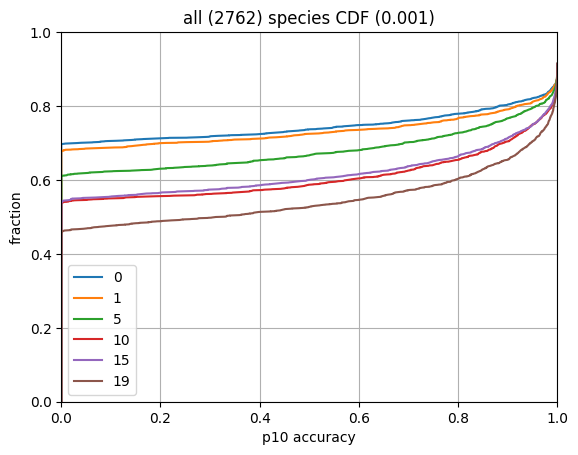

In [16]:
def plotCDF(coefficient_threshold: float = 0.001, max_changepoints=[0, 1, 5, 10, 15, 19], is_species: bool = True, col="p10",
        is_non_oscillating: Optional[bool] = None):
    # Construct the dataframe to process
    #path = os.path.join(cn.DATA_DIR, f"piecewise_predictions_{coefficient_threshold}.csv")
    path = os.path.join(cn.DATA_DIR, f"piecewise_predictions.csv")
    df = pd.read_csv(path)
    df["key"] = NONOSCILLATION_DF[cn.COL_SYSTEM_ID] + "_" + NONOSCILLATION_DF[cn.COL_SPECIES_NAME]
    if is_non_oscillating is not None:
        df["key"] = NONOSCILLATION_DF[cn.COL_SYSTEM_ID] + "_" + NONOSCILLATION_DF[cn.COL_SPECIES_NAME]
        #
        sel = df["key"].isin(NONOSCILLATION_DF["key"].unique())
        if is_non_oscillating:
            df = df[sel]
        else:
            df = df[~sel]
    #
    dct = {c: getColumn(df, col=col, max_changepoint = c, is_species=is_species) for c in max_changepoints}
    for key, value in dct.items():
        Score.plotCDFArray(value)
    ax = plt.gca()
    ax.legend([str(c) for c in max_changepoints])
    ax.set_xlabel(col + " accuracy")
    qualifier1 = "species" if is_species else "models"
    model_sel = (df[cn.COL_AGGREGATION_TYPE] == "model") & (df[cn.COL_MAX_CHANGEPOINT] == 0)
    species_sel = (df[cn.COL_AGGREGATION_TYPE] != "model") & (df[cn.COL_MAX_CHANGEPOINT] == 0)
    species_length = np.sum(species_sel)
    model_length = np.sum(model_sel)
    if is_species:
        length = species_length
    else:
        length = model_length
    if is_non_oscillating is None:
        qualifier2 = "all"
    else:
        qualifier2 = "non-oscillating" if is_non_oscillating else "oscillating"
    ax.set_title(f"{qualifier2} ({length}) {qualifier1} CDF ({coefficient_threshold})")

plotCDF(coefficient_threshold=0.001, is_species=True)

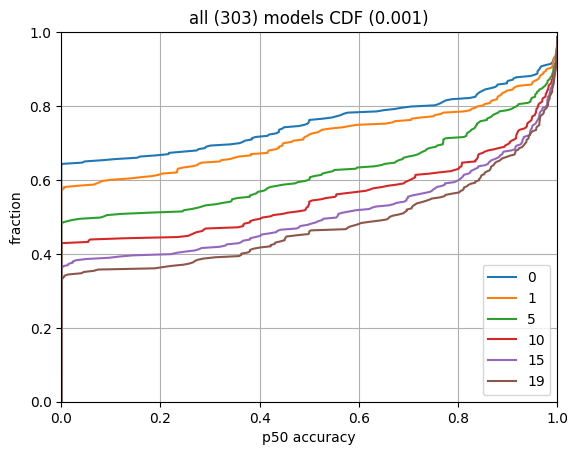

In [17]:
plotCDF(coefficient_threshold=0.001, is_species=False, col="p50")

**Observations**
1. Increasing the number of changepoints increases accuracy up to about 20 changepoints.
2. There is decreasing benefit of increasing the number of changepoints. For example, going from 0 to 1 changepoint, increases the fraction of p10 = 0.8  by 5%, but there is almost no increase the this fraction by increasing from 10 changepoints to 20 changepoints.
3. About 40% of the species trajectories have a p10 accuracy of 0 even if changepoints are considered.
4. The benefit of increasing changepoints diminishes with the p10 accuracy.
5. For 10 changepoints, approximately 50% of species have a p10 accuracy of 0.8 and 45% a p10 accuracy of 0.9.

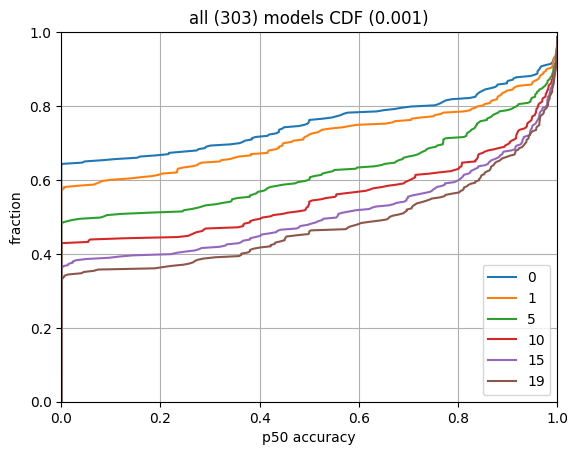

In [18]:
plotCDF(is_species = False, col="p50")

**Observations**
1. For 10 changepoints, approximately, 35% of models have a p10 accuracy of 0.8, and 30% of the models have a p10 accuracy of 0.9.
2. Accuracies for models are generally lower than those for species since a model combines many species and we are considering the tail of the distribution.
3. The other observations about species apply to models.

In [19]:
len(DF["system_id"].unique())

298

## Oscillating vs. Non-Oscillating Models

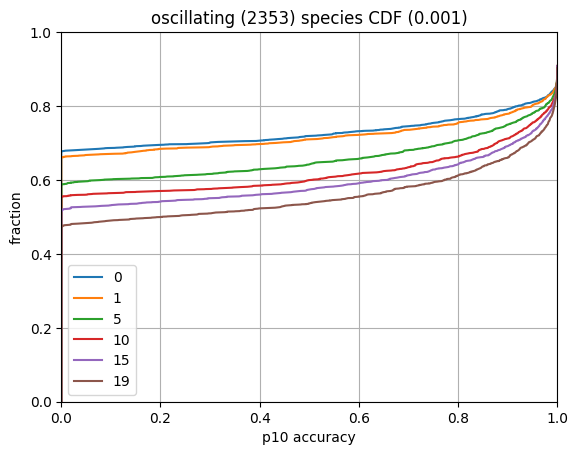

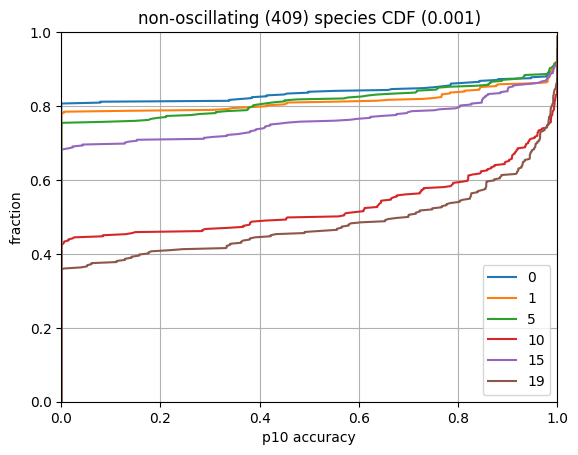

In [20]:
plotCDF(coefficient_threshold=0.001, is_species=True, is_non_oscillating=False)
plt.figure()
plotCDF(coefficient_threshold=0.001, is_species=True, is_non_oscillating=True)